## 1. Data Loading and Exploration

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Apple Stock Prices (1981 to 2023).csv')

### Initial Data Overview

In [2]:
# Display the first 5 rows of the DataFrame
display(df.head())

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


### Check for Missing Values

In [3]:
# Check for null values
display(df.isnull().sum())

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


### Data Types Information

In [4]:
# Get information about data types
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.3+ KB


None

### Chronological Properties

In [10]:
# Convert 'Date' to datetime and set as index
# Check if 'Date' is a column before attempting to convert and set as index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
    df = df.set_index('Date')
elif df.index.name == 'Date':
    # If 'Date' is already the index name, it means it has been processed.
    print(" 'Date' is already the DataFrame index. Skipping conversion and set_index.")
else:
    # This case implies 'Date' column is genuinely missing and it's not the index.
    # This might indicate an earlier error or unexpected DataFrame structure.
    # For now, we'll print a warning and assume the index is already appropriate for time series.
    print("Warning: 'Date' column not found and not set as index. Proceeding with current index, which may not be datetime.")

# Display date range
print(f"Date Range: {df.index.min()} to {df.index.max()}")

# Check frequency (e.g., daily, weekly, etc.) by looking at the difference between consecutive dates
print("\nDate frequency samples:")
print(df.index.to_series().diff().value_counts().head())

 'Date' is already the DataFrame index. Skipping conversion and set_index.
Date Range: 1981-01-02 00:00:00 to 2023-01-27 00:00:00

Date frequency samples:
Date
1 days    8317
3 days    1927
4 days     265
2 days      95
5 days       2
Name: count, dtype: int64


## 2. Data Visualization

### Closing Prices and Traded Volume Over Time

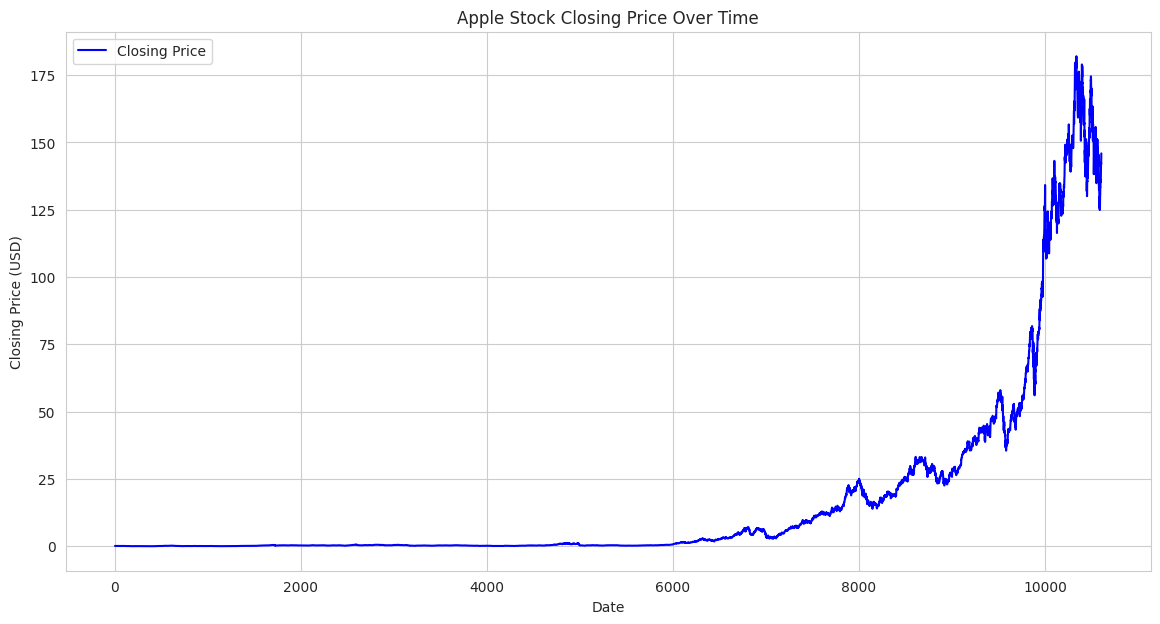

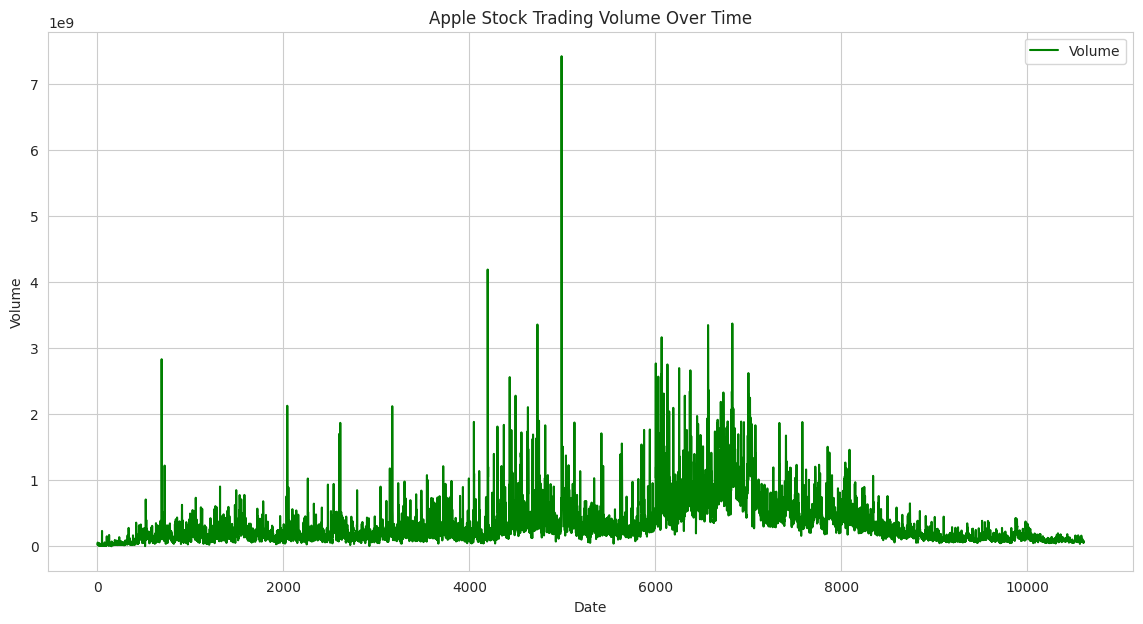

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Plotting Closing Price over Time
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
plt.title('Apple Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Volume Over Time
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Volume'], label='Volume', color='green')
plt.title('Apple Stock Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.grid(True)
plt.show()

### Candlestick Chart

In [7]:
import plotly.graph_objects as go

# Resample data for a more manageable candlestick chart (e.g., weekly or monthly)
# For a clearer view, let's resample to weekly data.
ohlc_data = df[['Open', 'High', 'Low', 'Close']].resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last'
})

fig = go.Figure(
    data=[go.Candlestick(
        x=ohlc_data.index,
        open=ohlc_data['Open'],
        high=ohlc_data['High'],
        low=ohlc_data['Low'],
        close=ohlc_data['Close']
    )]
)

fig.update_layout(
    title='Apple Stock Candlestick Chart (Weekly)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    xaxis_rangeslider_visible=False
)

fig.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'